# STA for Non-Hermitian PT Symmetric Heisenberg Chain

This notebook numerically studies the Counterdiabatic driving term for Non-Hermitian PT Symmetric Heisenberg chain. The Hamiltonian is given by
$$
H = \sum_{j=1}^{N-1} \sum_{\alpha = \{x,y,z\}}\sigma_j^\alpha \sigma_{j+1}^\alpha + h_1 \alpha_1^z + h_N\sigma_N^z
$$

In [22]:
include("PT_Heisenberg.jl")
using .PT_Heisenberg

include("B2_A2_Transition.jl")
using .B2_A2_Transition

include("AGP_Norm.jl")
using .AGP_Norm

include("KrylovKitAGP.jl")
using .KrylovKitAGP

include("KrylovAGP_Scan.jl")
using .KrylovAGP_Scan

In [23]:
results = KrylovAGP_Scan.scan_krylov_agp_norm(9, 1e-7);
#print_krylov_scan_table(results)

Scanning N=9, χ=1.0e-7,  ξ ∈ [-0.9, -0.4],  n_points=60
Krylov dims: [5, 17, 69, 399]
Using 10 thread(s)
────────────────────────────────────────────────────────────────────
  ξ=-0.9000 [B2]  exact=3.1079e+02  k=399: 3.0674e+02  (rel_err=1.30e-02)
  ξ=-0.8915 [B2]  exact=3.1899e+02  k=399: 3.1482e+02  (rel_err=1.31e-02)
  ξ=-0.8831 [B2]  exact=3.2739e+02  k=399: 3.2310e+02  (rel_err=1.31e-02)
  ξ=-0.8746 [B2]  exact=3.3602e+02  k=399: 3.3160e+02  (rel_err=1.32e-02)
  ξ=-0.8661 [B2]  exact=3.4488e+02  k=399: 3.4031e+02  (rel_err=1.32e-02)
  ξ=-0.8576 [B2]  exact=3.5398e+02  k=399: 3.4926e+02  (rel_err=1.33e-02)
  ξ=-0.8492 [B2]  exact=3.6334e+02  k=399: 3.5846e+02  (rel_err=1.34e-02)
  ξ=-0.8407 [B2]  exact=3.7297e+02  k=399: 3.6791e+02  (rel_err=1.36e-02)
  ξ=-0.8322 [B2]  exact=3.8287e+02  k=399: 3.7762e+02  (rel_err=1.37e-02)
  ξ=-0.8237 [B2]  exact=3.9306e+02  k=399: 3.8762e+02  (rel_err=1.38e-02)
  ξ=-0.8153 [B2]  exact=4.0356e+02  k=399: 3.9792e+02  (rel_err=1.40e-02)
  ξ=-0.8068 

(xi = [-0.9, -0.8915254237288136, -0.8830508474576271, -0.8745762711864407, -0.8661016949152542, -0.8576271186440678, -0.8491525423728814, -0.8406779661016949, -0.8322033898305085, -0.823728813559322  …  -0.47627118644067795, -0.46779661016949153, -0.45932203389830506, -0.45084745762711864, -0.4423728813559322, -0.43389830508474575, -0.42542372881355933, -0.41694915254237286, -0.40847457627118644, -0.4], exact = [310.7946739882358, 318.9882371185419, 327.39385038639426, 336.02146012809567, 344.8814758267061, 353.9846633889878, 363.3421332042786, 372.9654523907621, 382.86690318938713, 393.0598995616209  …  3770.3587214063027, 3593.3340255339926, 3645.980051097483, 3754.598907178877, 3866.1833035616664, 3960.98429730479, 4033.880905329517, 4092.2291896387565, 4166.427273383387, 4368.179485753914], krylov = Dict(5 => [35.328799562207664, 36.484180768742476, 37.685350968547695, 38.93439403452232, 40.23349724277519, 41.584956490256914, 42.9911817418935, 44.454702710177926, 45.97817476880364

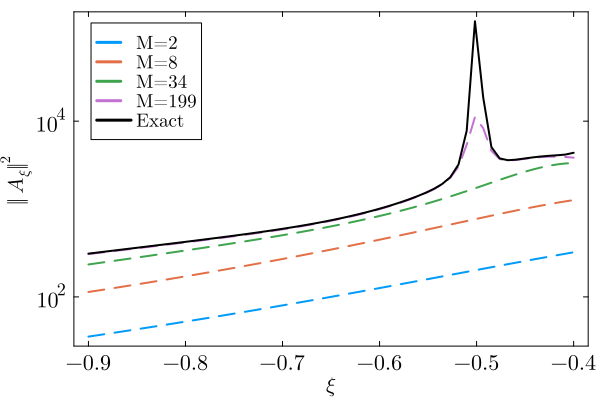

In [33]:
using Plots, LaTeXStrings
p = plot(xlabel=L"ξ", ylabel=L"‖A_ξ‖^2",
         yscale=:log10, legend=:topleft,  frame = :box, grid = false)
for k in results.krylov_dims
    AGP_dim = Int(floor(k/2))
    plot!(p, results.xi, results.krylov[k], label="M=$AGP_dim", linestyle=:dash, linewidth = 2)
end
plot!(p,titlefontsize=18, guidefontsize=16, tickfontsize=14, legendfontsize=12, labelfontsize = 14, fontfamily = "Computer Modern")
plot!(p, results.xi, results.exact, label="Exact", linewidth=2, color=:black)
# vline!(p, [-0.5], linestyle=:dot, color=:red, label = nothing)
# annotate!((0.85,0.1),text(L"ξ = −0.5",10))
#title="Krylov AGP convergence  (N=7, χ=1e-5)",
#savefig(p, "AGP_norm_Heisenberg.pdf")